In [ ]:
from os import listdir
from os.path import isfile, join

!git clone https://github.com/1fmusic/Audio_cat_dog_classification
cat_wav_files = ['Audio_cat_dog_classification/cats/'+f for f in listdir('Audio_cat_dog_classification/cats/') if isfile(join('Audio_cat_dog_classification/cats/', f)) and '.wav' in f and 'cat' in f]
dog_wav_files = ['Audio_cat_dog_classification/dogs/'+f for f in listdir('Audio_cat_dog_classification/dogs/') if isfile(join('Audio_cat_dog_classification/dogs/', f)) and '.wav' in f and 'dog' in f]


Cloning into 'Audio_cat_dog_classification'...
remote: Enumerating objects: 987, done.
remote: Total 987 (delta 0), reused 0 (delta 0), pack-reused 987 (from 1)
Receiving objects: 100% (987/987), 359.50 MiB | 11.70 MiB/s, done.
Resolving deltas: 100% (15/15), done.
Updating files: 100% (1025/1025), done.


In [ ]:

L_audios = []
L_y = []
for cat_audio in cat_wav_files:
  L_audios.append(cat_audio)
  L_y.append(0)

for dog_audio in dog_wav_files:
  L_audios.append(dog_audio)
  L_y.append(1)

In [ ]:
import torch
from transformers import Wav2Vec2Processor, Wav2Vec2Model
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import librosa
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# Carregar Wav2Vec
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h").to(device)

def extract_embeddings(file_paths):

    embeddings = []
    for file_path in tqdm(file_paths):
        # Carregar áudio
        audio, sr = librosa.load(file_path, sr=16000)  # Wav2Vec espera taxa de 16 kHz
        inputs = processor(audio, sampling_rate=16000, return_tensors="pt", padding=True).to(device)

        # Extrair embeddings
        with torch.no_grad():
            outputs = model(**inputs)
            hidden_states = outputs.last_hidden_state  # Shape: [batch_size, seq_len, hidden_dim]
            mean_embedding = torch.mean(hidden_states, dim=1).squeeze(0)  # Media sobre o tempo
            embeddings.append(mean_embedding.cpu().numpy())


    return embeddings

def train_and_evaluate_knn(file_paths, labels, test_size=0.2, random_state=42, n_neighbors=5):
    # Divisão treino-teste
    train_files, test_files, train_labels, test_labels = train_test_split(
        file_paths, labels, test_size=test_size, random_state=random_state
    )

    # Extrair embeddings
    print("Extraindo embeddings para o conjunto de treino...")
    train_embeddings = extract_embeddings(train_files)
    print("Extraindo embeddings para o conjunto de teste...")
    test_embeddings = extract_embeddings(test_files)

    # Treinar KNN
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(train_embeddings, train_labels)

    # Avaliar
    preds = knn.predict(test_embeddings)

    # Acurácia
    accuracy = accuracy_score(test_labels, preds)
    print(f"Acurácia no conjunto de teste: {accuracy * 100:.2f}%")

    # Matriz de confusão
    cm = confusion_matrix(test_labels, preds)
    print("\nMatriz de Confusão:")
    print(cm)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Matriz de Confusão")
    plt.show()

    # Relatório de classificação
    report = classification_report(test_labels, preds, target_names=[f"Classe {i}" for i in set(labels)])
    print("\nRelatório de Classificação:")
    print(report)

    return train_embeddings, test_embeddings, train_labels, test_labels



cuda


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.60k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Extraindo embeddings para o conjunto de treino...


  0%|          | 0/203 [00:00<?, ?it/s]

Extraindo embeddings para o conjunto de teste...


  0%|          | 0/51 [00:00<?, ?it/s]

Acurácia no conjunto de teste: 90.20%

Matriz de Confusão:
[[23  2]
 [ 3 23]]


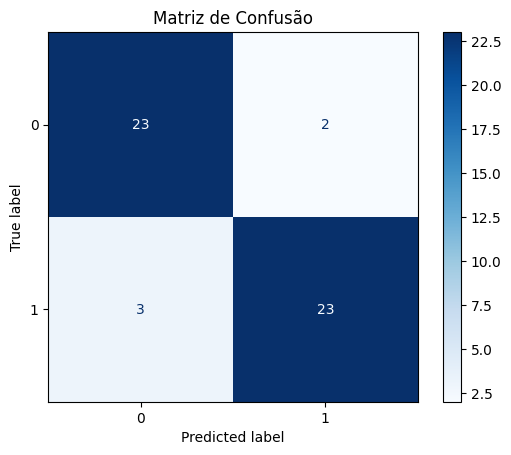


Relatório de Classificação:
              precision    recall  f1-score   support

    Classe 0       0.88      0.92      0.90        25
    Classe 1       0.92      0.88      0.90        26

    accuracy                           0.90        51
   macro avg       0.90      0.90      0.90        51
weighted avg       0.90      0.90      0.90        51



In [ ]:
train_embeddings, test_embeddings, train_labels, test_labels = train_and_evaluate_knn(L_audios, L_y)


In [ ]:
!pip install umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 5.1 MB/s eta 0:00:00


/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


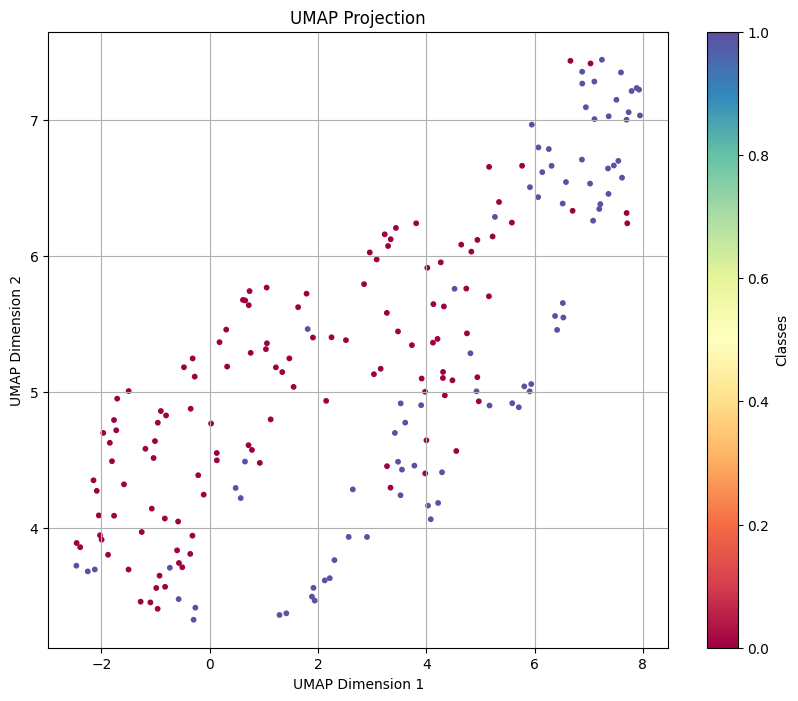

In [ ]:
import umap
import matplotlib.pyplot as plt
import numpy as np

def plot_umap(embeddings, labels, n_neighbors=15, min_dist=0.1, title="UMAP Projection"):

    # Converter para numpy array, se necessário
    embeddings = np.array(embeddings)
    labels = np.array(labels)

    # Reduzir dimensionalidade com UMAP
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, n_components=2, random_state=42)
    reduced_embeddings = reducer.fit_transform(embeddings)

    # Plot 2D
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(
        reduced_embeddings[:, 0], reduced_embeddings[:, 1], c=labels, cmap='Spectral', s=10
    )
    plt.colorbar(scatter, label="Classes")
    plt.title(title)
    plt.xlabel("UMAP Dimension 1")
    plt.ylabel("UMAP Dimension 2")
    plt.grid(True)
    plt.show()

plot_umap(train_embeddings, train_labels, n_neighbors=15, min_dist=0.1)
